In [49]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df= pd.read_excel('Data_PT. Amanah_Critical_Break - Copy.xlsx')
# df = df[df['Status'].isin(["Critical", "Break"])]
# df=df[df['Status']=="Critical"] 
df.head(5)

,Exhaust Gas Temperature LF (Left Front),Exhaust Gas Temperature LR (Left Rear),Exhaust Gas Temperature RF (Right Front),Exhaust Gas Temperature RR (Right Rear),Blowby Pressure (Kpa),Boost Pressure (Kpa),Engine Oil Temp (°C),Coolant Temp (°C),Unit Lifetime (Hour),Status,sisa jam
0,672.939,667.682,672.801,674.615,4.138,153.546,117.792,98.476,76070,Normal,2550
1,658.958,674.164,685.793,676.438,3.526,152.219,117.960,97.093,76071,Normal,2550
2,658.635,680.514,676.721,688.368,3.290,151.583,116.446,97.805,76072,Normal,2550
3,651.348,672.394,685.965,690.383,3.120,150.333,116.193,98.890,76073,Normal,2550
4,657.470,673.276,684.363,694.517,2.887,150.355,115.121,99.878,76074,Normal,2550


In [51]:
df=df.drop(columns='Status')
df=df.drop(columns='Unit Lifetime (Hour)')

In [52]:
df = df.astype({
    'Exhaust Gas Temperature LF (Left Front)': 'float',
    'Exhaust Gas Temperature LR (Left Rear)': 'float',
    'Exhaust Gas Temperature RF (Right Front)': 'float',
    'Exhaust Gas Temperature RR (Right Rear)': 'float',
    'Blowby Pressure (Kpa)': 'float',
    'Boost Pressure (Kpa)': 'float',
    'Engine Oil Temp (°C)': 'float',
    'Coolant Temp (°C)': 'float',
    
    'sisa jam':'float'
})

In [53]:
feature_columns = [
    "Exhaust Gas Temperature LF (Left Front)",
    "Exhaust Gas Temperature LR (Left Rear)",
    "Exhaust Gas Temperature RF (Right Front)",
    "Exhaust Gas Temperature RR (Right Rear)",
    "Blowby Pressure (Kpa)",
    "Boost Pressure (Kpa)",
    "Engine Oil Temp (°C)",
    "Coolant Temp (°C)",
]

target_column = "sisa jam"

X = df[feature_columns]
y = df[target_column]

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


### ABC SVR

In [ ]:
svr_pipeline = Pipeline([
    
    
    ("scaler", StandardScaler()),
    
    
    ("svr", SVR(
        kernel="rbf",
        C=1000,
        epsilon=0.001,
        gamma=0.2608780517170326
    ))
])


In [56]:
svr_pipeline.fit(
    X_train,
    y_train
)

print("Model SVR berhasil dilatih!")

Model SVR berhasil dilatih!


In [57]:
joblib.dump(
    svr_pipeline,
    "model_svr(new).pkl"
)

print("Model berhasil disimpan sebagai: model_svr.pkl")

Model berhasil disimpan sebagai: model_svr.pkl


### PSO RANDOM FORREST

In [ ]:
RF_pipeline = Pipeline([
    
    
    
    ("Rf", RandomForestRegressor(
        n_estimators      = 215,
        max_depth         = 18,
        min_samples_split = 2,
        min_samples_leaf  = 1,
        max_features      = 0.5685504664576413
    ))
])

In [59]:
RF_pipeline.fit(
    X_train,
    y_train
)

print("Model Rf berhasil dilatih!")

Model Rf berhasil dilatih!


In [60]:
joblib.dump(
    svr_pipeline,
    "model_Rf(new).pkl"
)

print("Model berhasil disimpan sebagai: model_Rf.pkl")

Model berhasil disimpan sebagai: model_Rf.pkl


### Buat Grafik

In [94]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

In [95]:
model = joblib.load("model_svr(new).pkl")

print("Model SVR berhasil dimuat!")

Model SVR berhasil dimuat!


In [ ]:

df = pd.read_excel(
    "Data_PT. Amanah_Critical_Break - Copy.xlsx",
    sheet_name="Sheet1",
    header=0
)

print("Jumlah data:", len(df))

print("\nKolom dataset:")
print(df.columns.tolist())


Jumlah data: 2567

Kolom dataset:
['Exhaust Gas Temperature LF (Left Front)', 'Exhaust Gas Temperature LR (Left Rear)', 'Exhaust Gas Temperature RF (Right Front)', 'Exhaust Gas Temperature RR (Right Rear)', 'Blowby Pressure (Kpa)', 'Boost Pressure (Kpa)', 'Engine Oil Temp (°C)', 'Coolant Temp (°C)', 'Unit Lifetime (Hour)', 'Status', 'sisa jam']


In [97]:
df = df.astype({
    'Exhaust Gas Temperature LF (Left Front)': 'float',
    'Exhaust Gas Temperature LR (Left Rear)': 'float',
    'Exhaust Gas Temperature RF (Right Front)': 'float',
    'Exhaust Gas Temperature RR (Right Rear)': 'float',
    'Blowby Pressure (Kpa)': 'float',
    'Boost Pressure (Kpa)': 'float',
    'Engine Oil Temp (°C)': 'float',
    'Coolant Temp (°C)': 'float',
    
    'sisa jam':'float',
})

In [98]:
feature_columns = [
    "Exhaust Gas Temperature LF (Left Front)",
    "Exhaust Gas Temperature LR (Left Rear)",
    "Exhaust Gas Temperature RF (Right Front)",
    "Exhaust Gas Temperature RR (Right Rear)",
    "Blowby Pressure (Kpa)",
    "Boost Pressure (Kpa)",
    "Engine Oil Temp (°C)",
    "Coolant Temp (°C)",
]

X = df[feature_columns]

In [99]:
df["Predicted RUL"] = model.predict(X)

print("\nPrediksi berhasil dilakukan!")

print(
    df[[
        "Predicted RUL"
    ]].head()
)


Prediksi berhasil dilakukan!
   Predicted RUL
0    2482.923099
1    2506.722700
2    2534.774631
3    2550.001515
4    2554.444880


In [100]:
df.to_excel(
    "hasil_prediksi_rul_svr_kalimantan.xlsx",
    index=False
)

print("\nHasil prediksi disimpan:")
print("hasil_prediksi_rul.xlsx")


Hasil prediksi disimpan:
hasil_prediksi_rul.xlsx


In [101]:
df=pd.read_excel('hasil_prediksi_rul_svr_kalimantan.xlsx')

In [102]:
df = df.astype({
    'Exhaust Gas Temperature LF (Left Front)': 'float',
    'Exhaust Gas Temperature LR (Left Rear)': 'float',
    'Exhaust Gas Temperature RF (Right Front)': 'float',
    'Exhaust Gas Temperature RR (Right Rear)': 'float',
    'Blowby Pressure (Kpa)': 'float',
    'Boost Pressure (Kpa)': 'float',
    'Engine Oil Temp (°C)': 'float',
    'Coolant Temp (°C)': 'float',
    'Unit Lifetime (Hour)' : 'float'
    
    # 'sisa jam':'float',
})

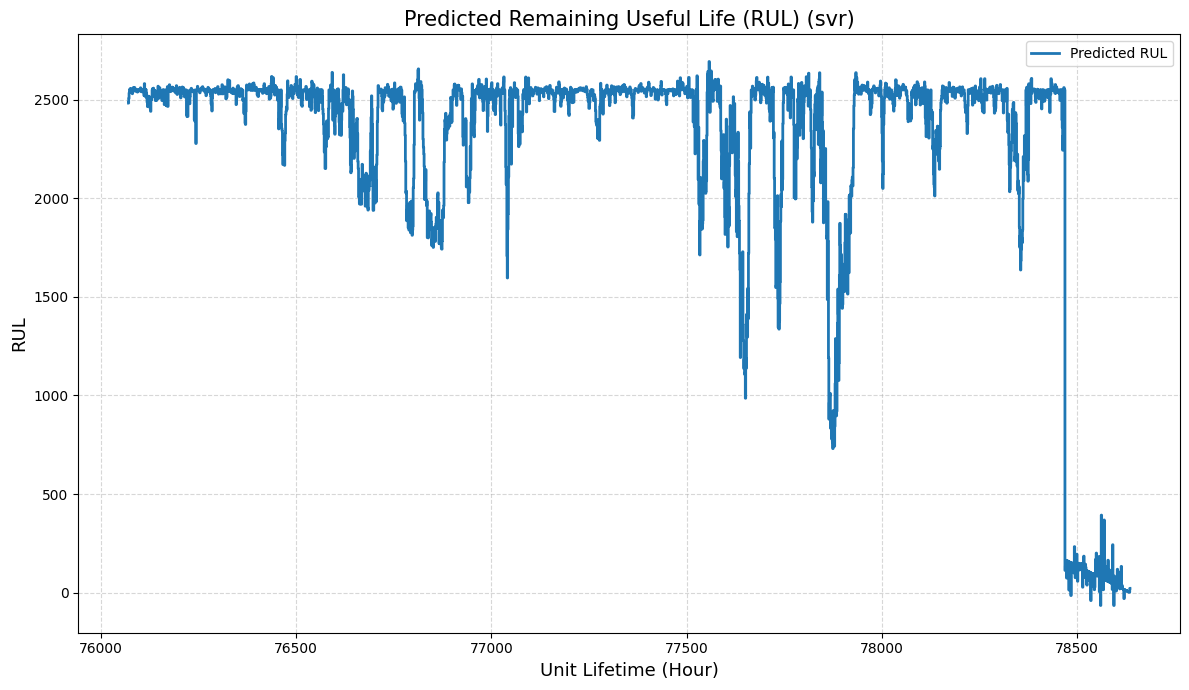

In [ ]:

x_column = "Unit Lifetime (Hour)"



plt.figure(figsize=(12, 7))


# plt.plot(
#     df[x_column],
#     df["Predicted RUL"],
#     linewidth=2,
#     marker="s",
#     markersize=3,
#     label="Predicted RUL"
# )
plt.step(
    df["Unit Lifetime (Hour)"],
    df["Predicted RUL"],
    where="mid",
    linewidth=2,
    label="Predicted RUL"
)

plt.xlabel(
    "Unit Lifetime (Hour)",
    fontsize=13
)

plt.ylabel(
    "RUL",
    fontsize=13
)

plt.title(
    "Predicted Remaining Useful Life (RUL) (svr)",
    fontsize=15
)

plt.legend()

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()


plt.savefig(
    "predicted_rul_vs_unit_lifetime.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()